In [4]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# breaking

In [12]:
# load data
from scipy.optimize import curve_fit
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis
from superconductivity.utilities.functions.upsampling import upsample
from mar_fit import prepare_mar_trace


def linear(x, a, b):
    return +a * x + b


Vbias = np.linspace(-0.5, 4.5, 501)
Ibias = np.linspace(-0.5, 4.5, 501)

plateau = "abcdde"
regions = "abcdef"
channels = [7, 6, 3, 2, 2, 1]
i_skip = [0, 9, 19, 71, 206, 262]
ii = [7, 13, 30, 83, 200, 230]

datafit = np.load("breaking/fit_data.npz", allow_pickle=True)
datasim = np.load("breaking/sim.npz", allow_pickle=True)
datatun = np.load("breaking/tunnel_eva.npz")

Vtunnel_mV = datatun["Vbias_mV"]
Itunnelup_nA = datatun["Iup_nA"]
Itunneldown_nA = datatun["Idown_nA"]
xtunnel_arbu = datatun["x_arbu"]

xtunnel_arbu -= xtunnel_arbu[0]
dGtunnel_G0 = np.gradient(Itunnelup_nA, Vtunnel_mV, axis=-1) / sc.G0_muS
GNtunnel_G0 = np.nanmean(dGtunnel_G0, axis=-1)
lnGNtunnel_G0 = np.log(GNtunnel_G0)
validtunnel = np.isfinite(lnGNtunnel_G0)
(m, c), pcov = curve_fit(
    linear,
    xtunnel_arbu[validtunnel],
    lnGNtunnel_G0[validtunnel],
    # p0=(-0.01, -8),
)
kappa_AA = 1.05  # nm
alpha_x_AA = np.abs(m) / (kappa_AA)  # AA/arbu

x_arbu = datafit["x_arbu"]
Vbias0_mV = datafit["V_mV"]
Iexp0_nA = datafit["Iexp_nA"]
Ifit0_nA = datafit["Ifit_nA"]
Isim0_nA = datasim["Isim_nA"]

taus = datafit["taus"]
GN_G0 = datafit["GN_G0"]
Delta_meV = datafit["Delta_meV"][0]

Vbias0 = Vbias0_mV / Delta_meV
x_AA = alpha_x_AA * (x_arbu - x_arbu[262])
xtunnel_AA = alpha_x_AA * xtunnel_arbu
Ifit0 = Ifit0_nA / (Delta_meV * GN_G0[:, np.newaxis] * sc.G0_muS)
Iexp0 = Iexp0_nA / (Delta_meV * GN_G0[:, np.newaxis] * sc.G0_muS)
Isim0 = datasim["Isim"]
# taus[taus == 0.0] = np.nan

Ifit = np.full((len(x_arbu), Vbias.shape[0]), np.nan)
Iexp = np.full((len(x_arbu), Vbias.shape[0]), np.nan)
Isim = np.full((len(x_arbu), Vbias.shape[0]), np.nan)

Vfit = np.full((len(x_arbu), Ibias.shape[0]), np.nan)
Vexp = np.full((len(x_arbu), Ibias.shape[0]), np.nan)
Vsim = np.full((len(x_arbu), Ibias.shape[0]), np.nan)

for i, xi_arbu in enumerate(x_arbu):

    maskfit = np.isfinite(Ifit0[i, :])
    if np.sum(maskfit) > 2:
        Ifit[i, :] = sc.nanbin_y_over_x(
            upsample(Ifit0[i, maskfit], axis=-1),
            upsample(Vbias0[maskfit], axis=-1),
            Vbias,
        )
        Vfit[i, :] = sc.nanbin_y_over_x(
            upsample(Vbias0[maskfit], axis=-1),
            upsample(Ifit0[i, maskfit], axis=-1),
            Ibias,
        )

    maskexp = np.isfinite(Iexp0[i, :])
    if np.sum(maskexp) > 2:
        Iexp[i, :] = sc.nanbin_y_over_x(
            upsample(Iexp0[i, maskexp], axis=-1),
            upsample(Vbias0[maskexp], axis=-1),
            Vbias,
        )

        Vexp[i, :] = sc.nanbin_y_over_x(
            upsample(Vbias0[maskexp], axis=-1),
            upsample(Iexp0[i, maskexp], axis=-1),
            Ibias,
        )

    masksim = np.isfinite(Isim0[i, :])
    if np.sum(masksim) > 2:
        Isim[i, :] = sc.nanbin_y_over_x(
            upsample(Isim0[i, masksim], axis=-1),
            upsample(Vbias0[masksim], axis=-1),
            Vbias,
        )

        Vsim[i, :] = sc.nanbin_y_over_x(
            upsample(Vbias0[masksim], axis=-1),
            upsample(Isim0[i, masksim], axis=-1),
            Ibias,
        )

dGexp = np.gradient(Iexp, Vbias, axis=-1)
dGfit = np.gradient(Ifit, Vbias, axis=-1)
dGsim = np.gradient(Isim, Vbias, axis=-1)

dRexp = np.gradient(Vexp, Ibias, axis=-1)
dRfit = np.gradient(Vfit, Ibias, axis=-1)
dRsim = np.gradient(Vsim, Ibias, axis=-1)

/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_5228/1057635400.py:33: RuntimeWarning: invalid value encountered in log
  lnGNtunnel_G0 = np.log(GNtunnel_G0)
/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_5228/1057635400.py:57: RuntimeWarning: divide by zero encountered in divide
  Ifit0 = Ifit0_nA / (Delta_meV * GN_G0[:, np.newaxis] * sc.G0_muS)
/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_5228/1057635400.py:57: RuntimeWarning: invalid value encountered in divide
  Ifit0 = Ifit0_nA / (Delta_meV * GN_G0[:, np.newaxis] * sc.G0_muS)
/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_5228/1057635400.py:58: RuntimeWarning: divide by zero encountered in divide
  Iexp0 = Iexp0_nA / (Delta_meV * GN_G0[:, np.newaxis] * sc.G0_muS)


In [18]:
taus

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(268, 12))

In [ ]:
# cal
exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=x_AA[::3],
    Ibias=Ibias,
    Iexp=Iexp[::3, :],
    dGexp=dGexp[::3, :],
    dRexp=dRexp[::3, :],
    Alabel="$\\Delta x\\ (\\mathring{\\mathrm{A}})$",
    Ilim=(0, 5.5),
    dGlim=(0, 3.5),
    dGticks=[0, 1, 2, 3],
    Abiaslim=(-5.25, 0),
    Abiasticks=[-4, -2, 0],
    waterfall_traces=[-5, -4, -3, -2, -1],
    name="cal",
    sub_dir=f"atomic_contact/breaking/",
)

In [ ]:
# sim
exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=x_arbu[::3],
    Ibias=Ibias,
    Iexp=Isim[::3, :],
    dGexp=dGsim[::3, :],
    dRexp=dRsim[::3, :],
    Alabel="$\\Delta x\\ (\\mathrm{arb.u.})$",
    Ilim=(0, 5.5),
    dGlim=(0, 3.5),
    dGticks=[0, 1, 2, 3],
    Abiaslim=(-2.62, 0),
    Abiasticks=[-2, -1, 0],
    waterfall_traces=[-2.5, -2.0, -1.5, -1.0, -0.5, -0.05],
    name="sim",
    sub_dir=f"atomic_contact/breaking/",
)

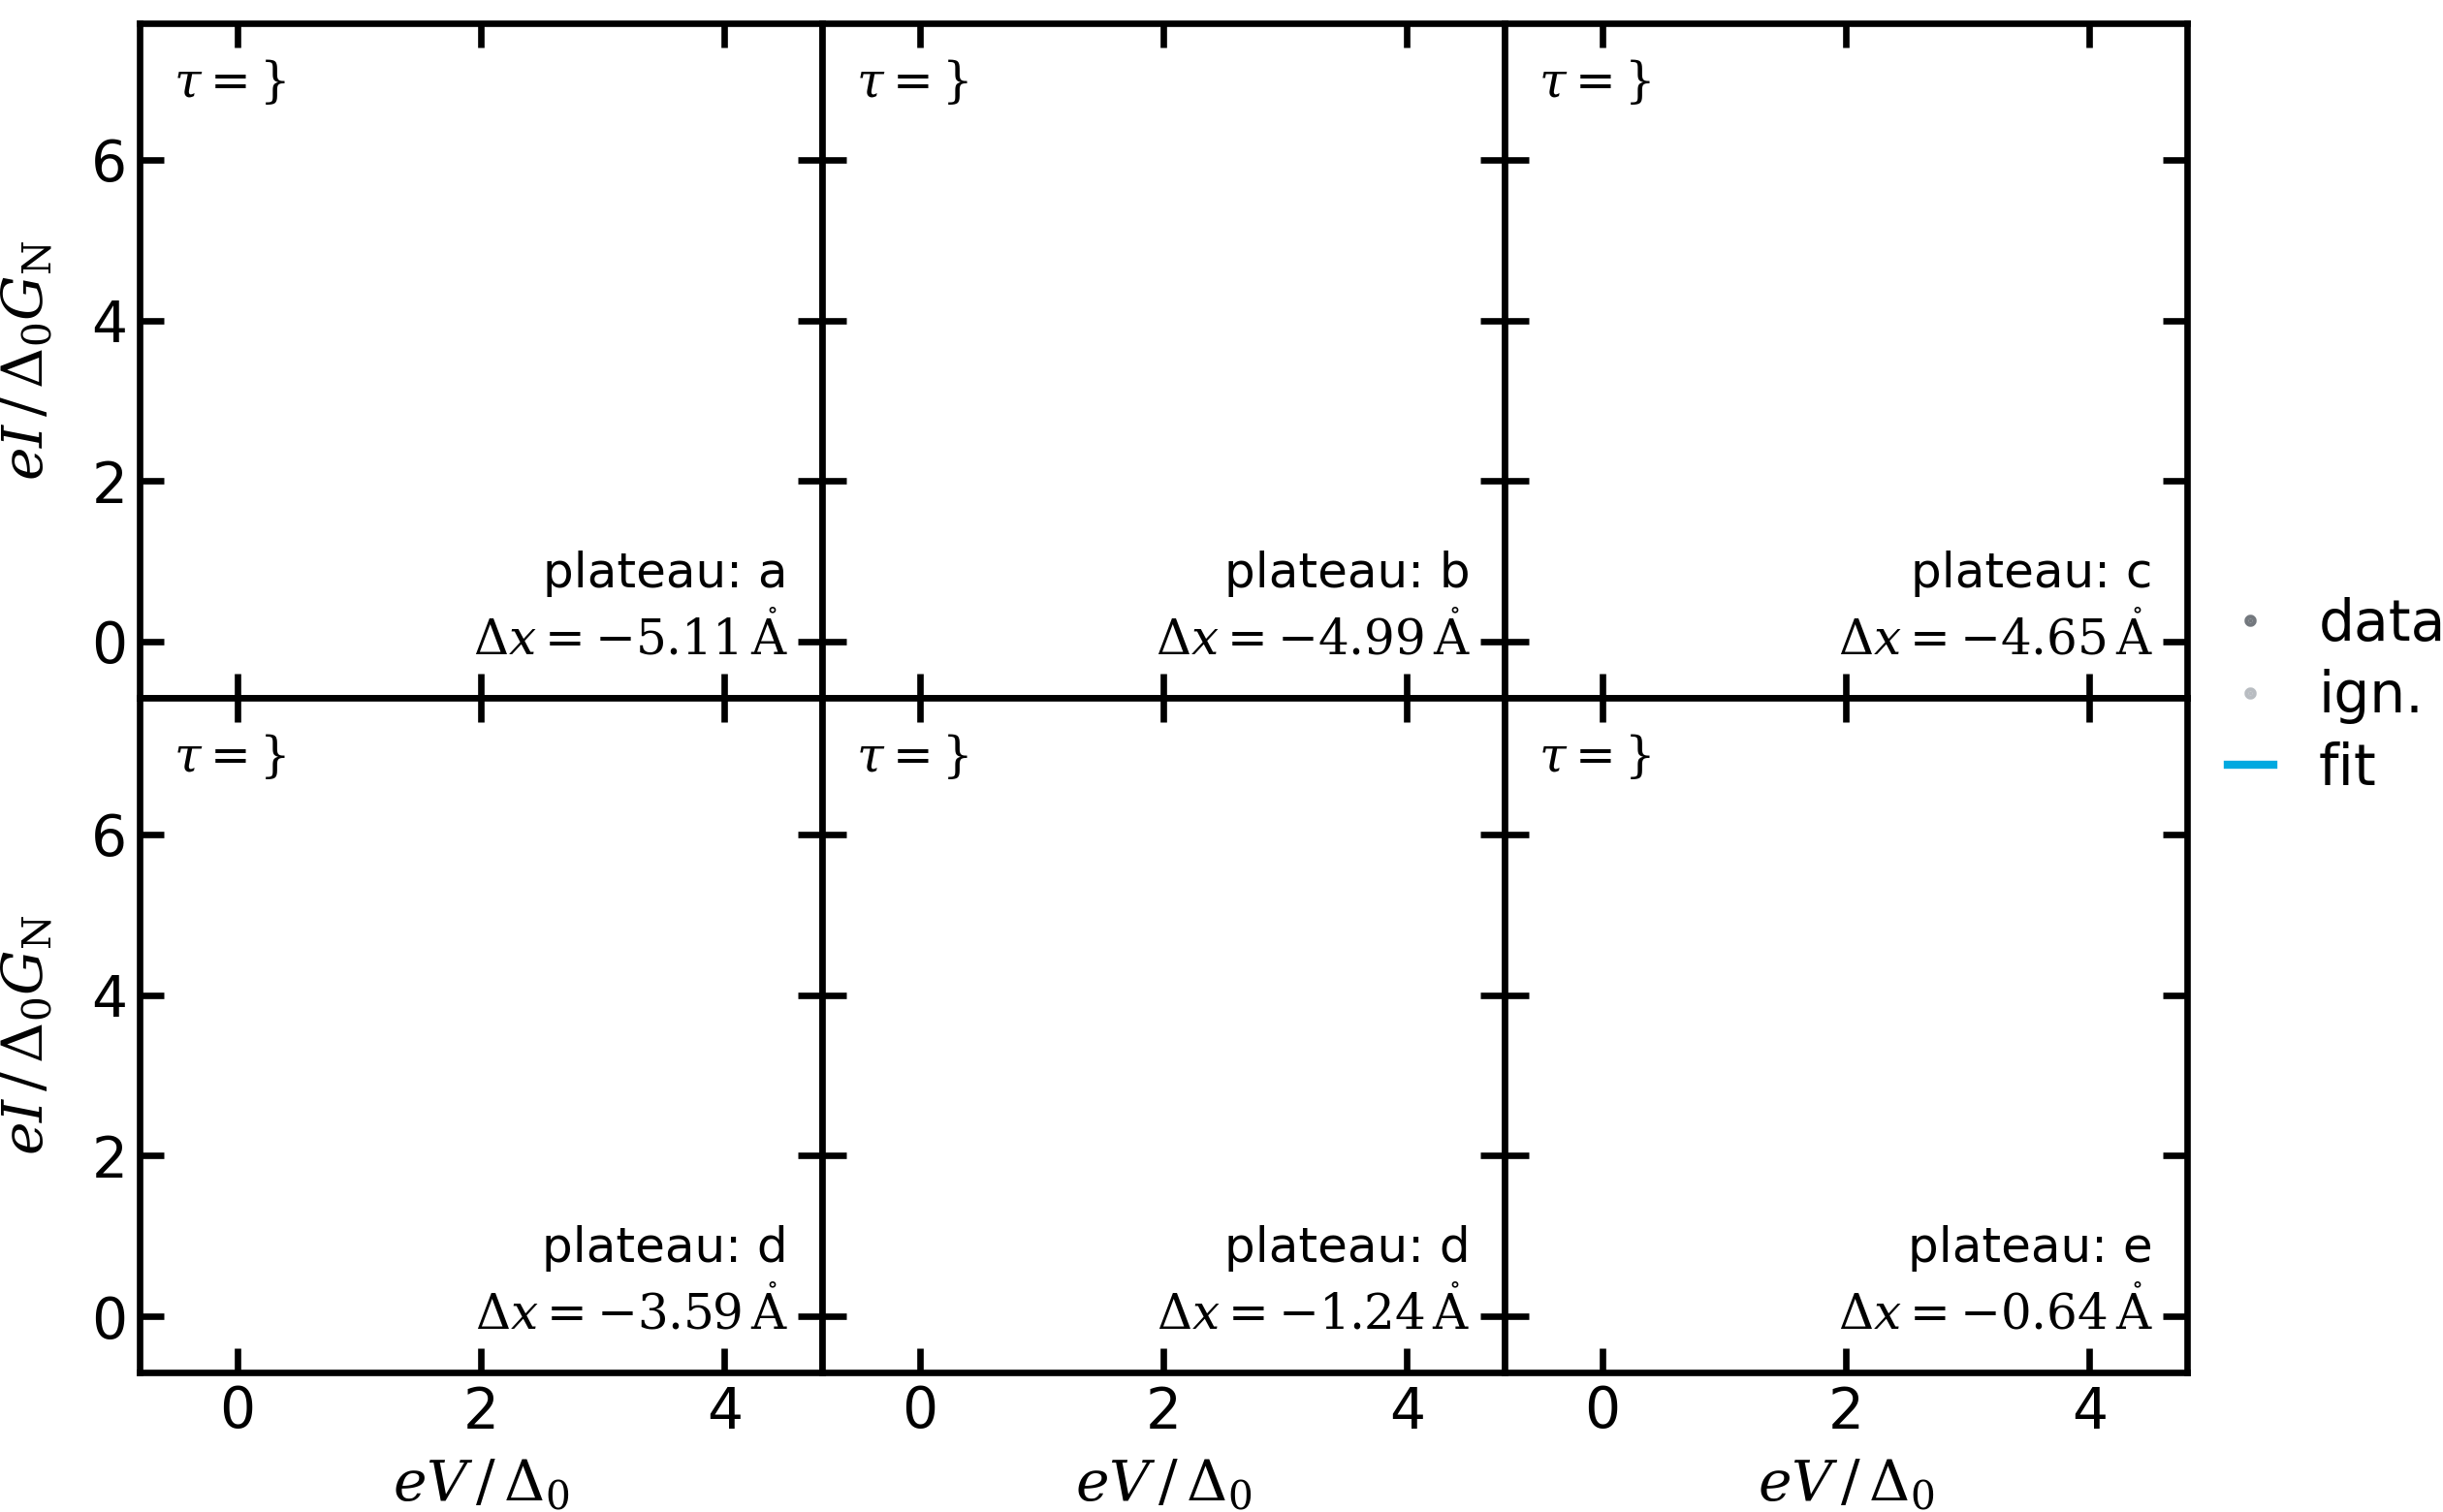

In [13]:
# ivs
fig, axes = sc.get_figures(
    figsize=(4.2, 2.6),
    padding=(0.2, 0.2, 0.4, 0.0),
    nrows=2,
    ncols=3,
)

j = 0
for i, xi_AA in enumerate(x_AA):
    if i in ii:
        # if True:
        mask = prepare_mar_trace(
            Vbias * Delta_meV,
            Iexp[i, :],
            Vnan_mV=0.04,
        )
        not_mask = np.logical_not(mask)
        axes[j].plot(Vbias[mask], Iexp[i, mask], ".", color=sc.seegrau100, zorder=0)
        axes[j].plot(
            Vbias[not_mask],
            Iexp[i, not_mask],
            ".",
            color=sc.seegrau35,
            zorder=0,
        )
        axes[j].plot(
            np.where(mask, Vbias, np.nan),
            np.where(mask, Ifit[i, :], np.nan),
            "-",
            color=sc.seeblau100,
            zorder=1,
        )

        taustring = "$\\tau=\\{"
        k = 0
        for taui in taus[i, :]:
            if np.logical_and(np.isfinite(taui), taui != 0.0):
                if k % 3 == 0 and k > 0:
                    taustring += "$\n       $\\,"
                taustring += f"{taui:.3f}, "
                k += 1
        taustring = taustring[:-2] + "\\}$"
        axes[j].text(
            0.05,
            0.95,
            taustring,
            transform=axes[j].transAxes,
            ha="left",
            va="top",
            size=6,
        )
        axes[j].text(
            0.95,
            0.05,
            f"$\\Delta x = {xi_AA:.2f}$" + "$\\,\\mathring{\\mathrm{A}}$",
            transform=axes[j].transAxes,
            ha="right",
            va="bottom",
            size=6,
        )
        axes[j].text(
            0.95,
            0.15,
            f"plateau: {plateau[j]}",
            transform=axes[j].transAxes,
            ha="right",
            va="bottom",
            size=6,
        )
        axes[j].set_xlim(-0.8, 4.8)
        axes[j].set_ylim(-0.7, 7.7)
        j += 1

axes[5].plot([], [], ".", color=sc.seegrau100, label="data")
axes[5].plot([], [], ".", color=sc.seegrau35, label="ign.")
axes[5].plot([], [], "-", color=sc.seeblau100, label="fit")

axes[5].legend(
    handlelength=0.8,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.01, 1.2),
)

axes = sc.daumenkino_layout(
    fig,
    axes,
    title="atomic_contact/breaking/ivs",
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$eI\\,/\\,\\Delta_0 G_\\mathrm{N}$",
    xticks=[0, 2, 4],
    yticks=[0, 2, 4, 6],
)

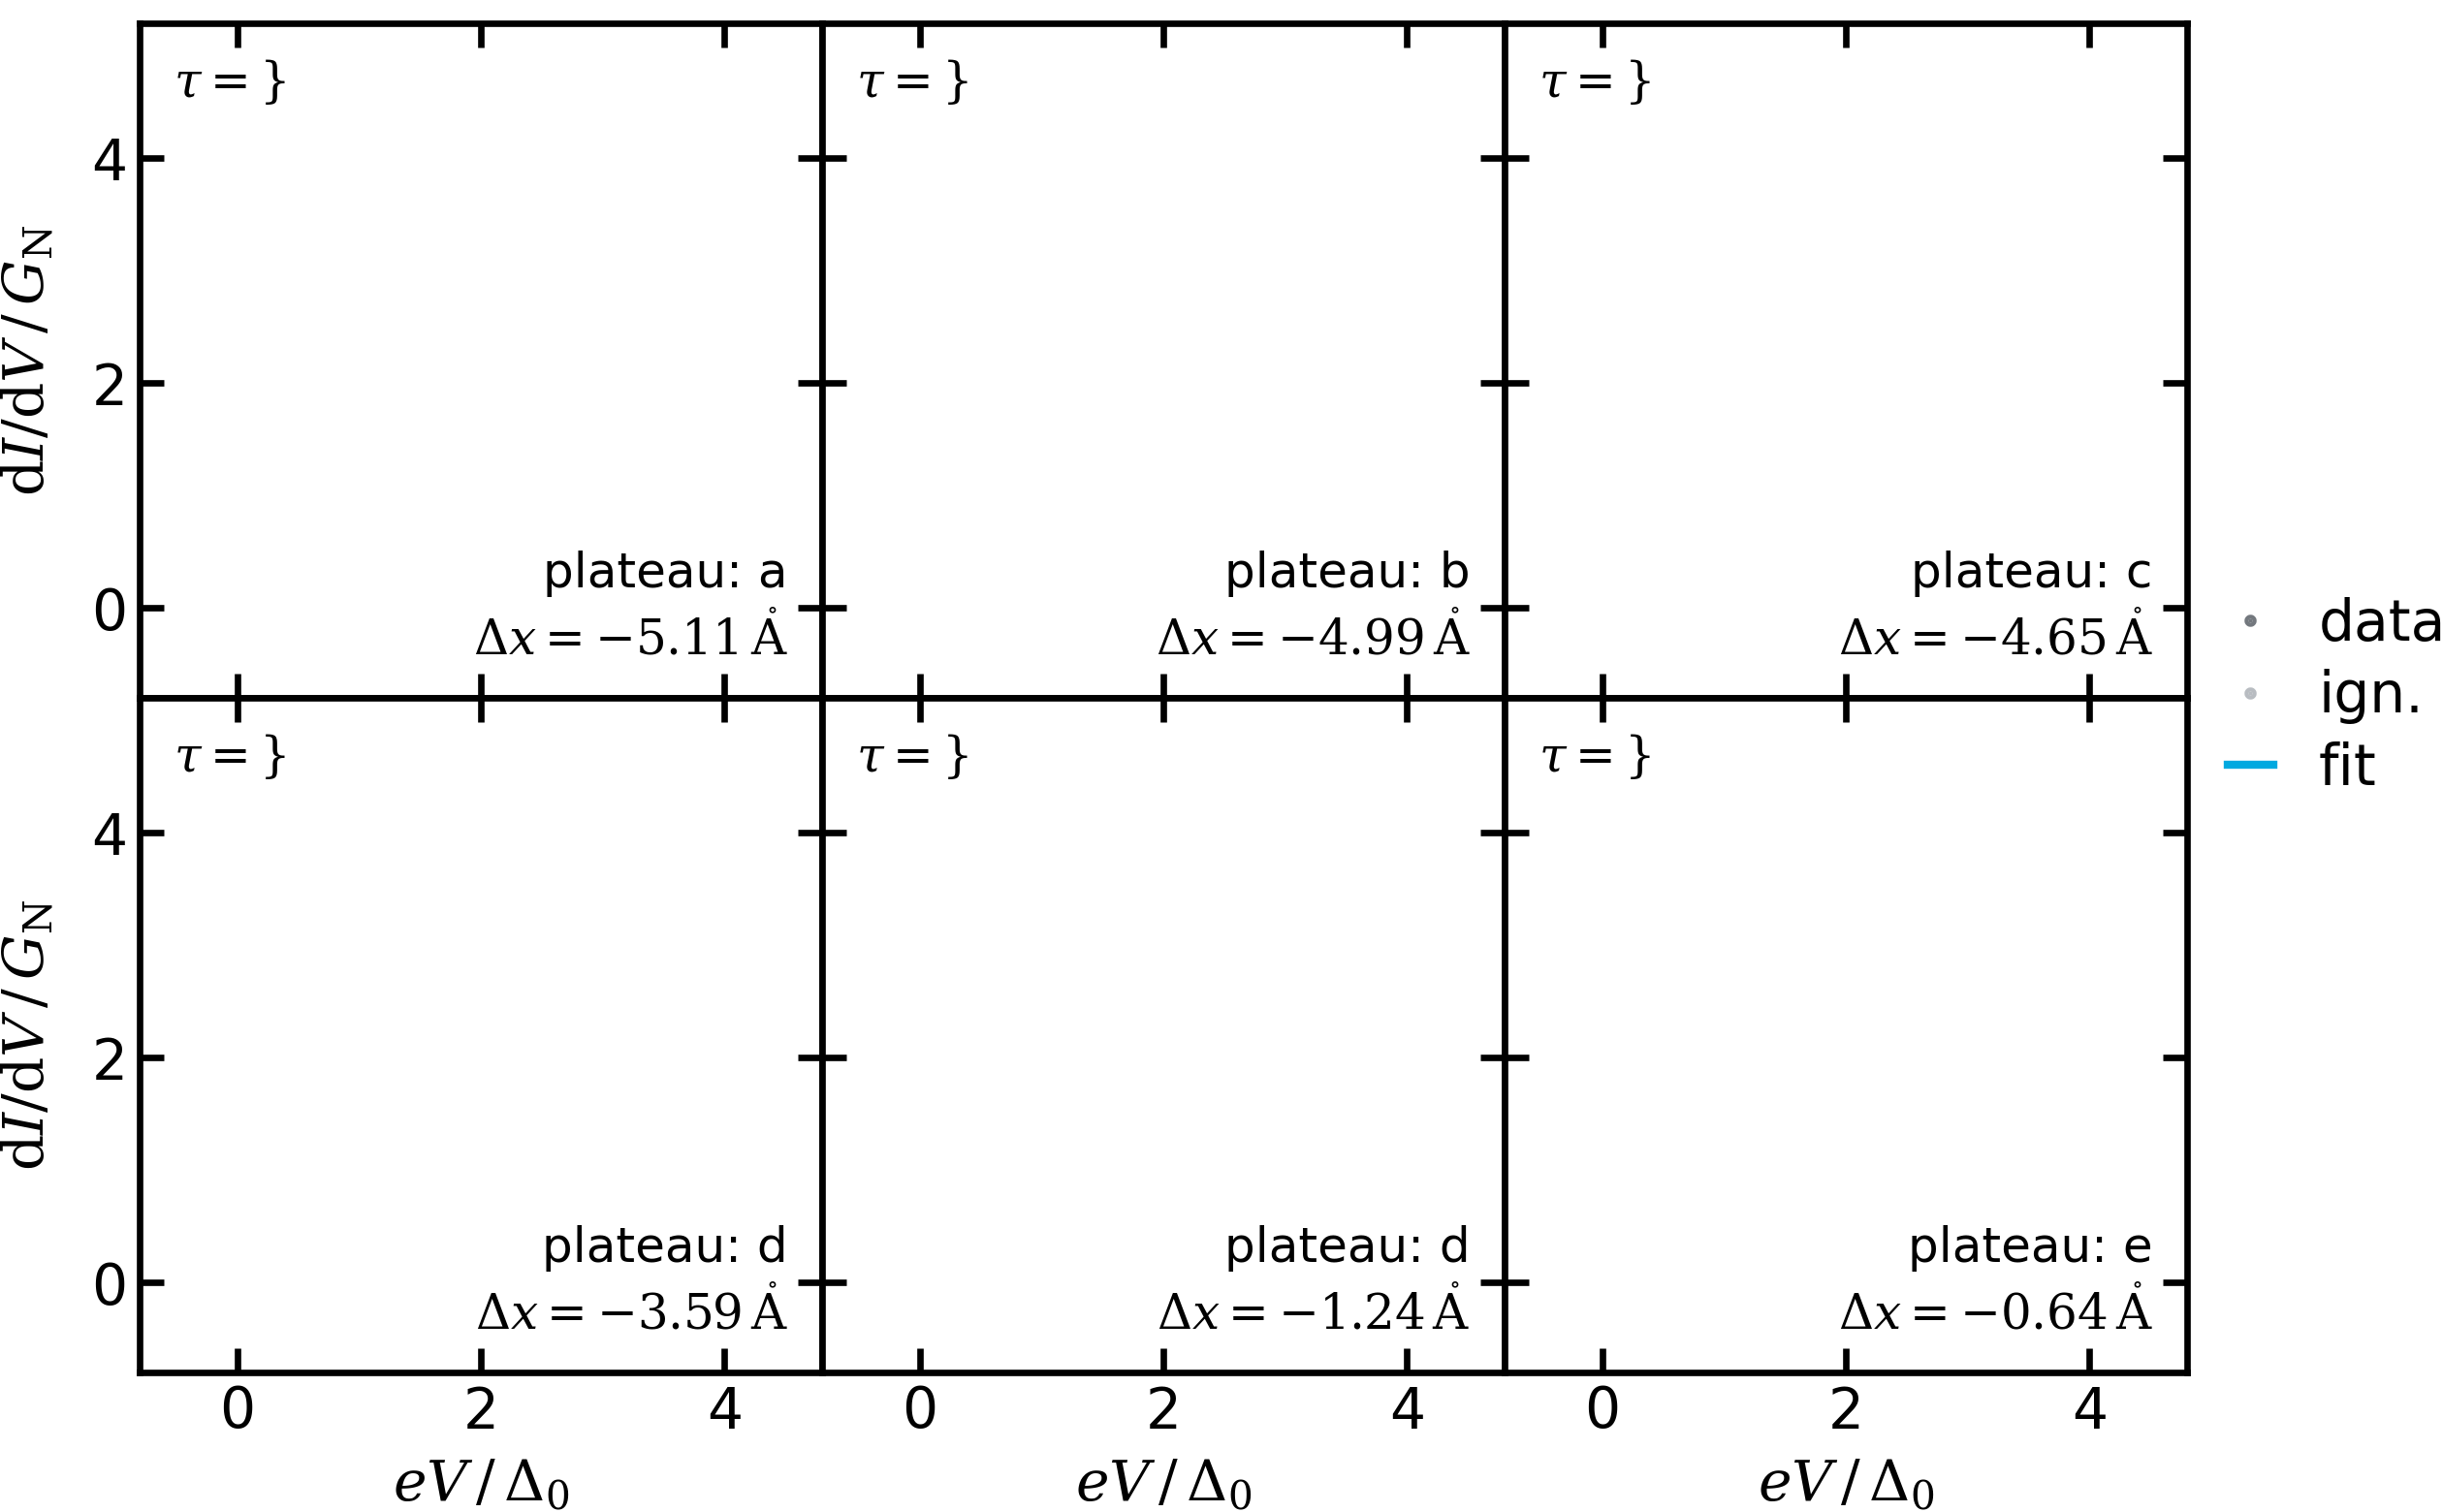

In [14]:
# didvs
fig, axes = sc.get_figures(
    figsize=(4.2, 2.6),
    padding=(0.2, 0.2, 0.4, 0.0),
    nrows=2,
    ncols=3,
)

j = 0
for i, xi_AA in enumerate(x_AA):
    if i in ii:
        # if True:
        mask = prepare_mar_trace(
            Vbias * Delta_meV,
            Iexp[i, :],
            Vnan_mV=0.06,
        )
        not_mask = np.logical_not(mask)
        axes[j].plot(Vbias[mask], dGexp[i, mask], ".", color=sc.seegrau100, zorder=0)
        axes[j].plot(
            Vbias[not_mask], dGexp[i, not_mask], ".", color=sc.seegrau35, zorder=0
        )
        axes[j].plot(
            np.where(mask, Vbias, np.nan),
            np.where(mask, dGfit[i, :], np.nan),
            "-",
            color=sc.seeblau100,
            zorder=1,
        )

        taustring = "$\\tau=\\{"
        k = 0
        for taui in taus[i, :]:
            if np.logical_and(np.isfinite(taui), taui != 0.0):
                if k % 3 == 0 and k > 0:
                    taustring += "$\n       $\\,"
                taustring += f"{taui:.3f}, "
                k += 1
        taustring = taustring[:-2] + "\\}$"
        axes[j].text(
            0.05,
            0.95,
            taustring,
            transform=axes[j].transAxes,
            ha="left",
            va="top",
            size=6,
        )
        axes[j].text(
            0.95,
            0.05,
            f"$\\Delta x = {xi_AA:.2f}$" + "$\\,\\mathring{\\mathrm{A}}$",
            transform=axes[j].transAxes,
            ha="right",
            va="bottom",
            size=6,
        )
        axes[j].text(
            0.95,
            0.15,
            f"plateau: {plateau[j]}",
            transform=axes[j].transAxes,
            ha="right",
            va="bottom",
            size=6,
        )
        axes[j].set_xlim(-0.8, 4.8)
        axes[j].set_ylim(-0.8, 5.2)
        j += 1


axes[5].plot([], [], ".", color=sc.seegrau100, label="data")
axes[5].plot([], [], ".", color=sc.seegrau35, label="ign.")
axes[5].plot([], [], "-", color=sc.seeblau100, label="fit")

axes[5].legend(
    handlelength=0.8,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.01, 1.2),
)

axes = sc.daumenkino_layout(
    fig,
    axes,
    title="atomic_contact/breaking/didvs",
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel=r"$\mathrm{d}I/\mathrm{d}V\,/\,G_\mathrm{N}$",
    xticks=[0, 2, 4],
    yticks=[0, 2, 4],
)

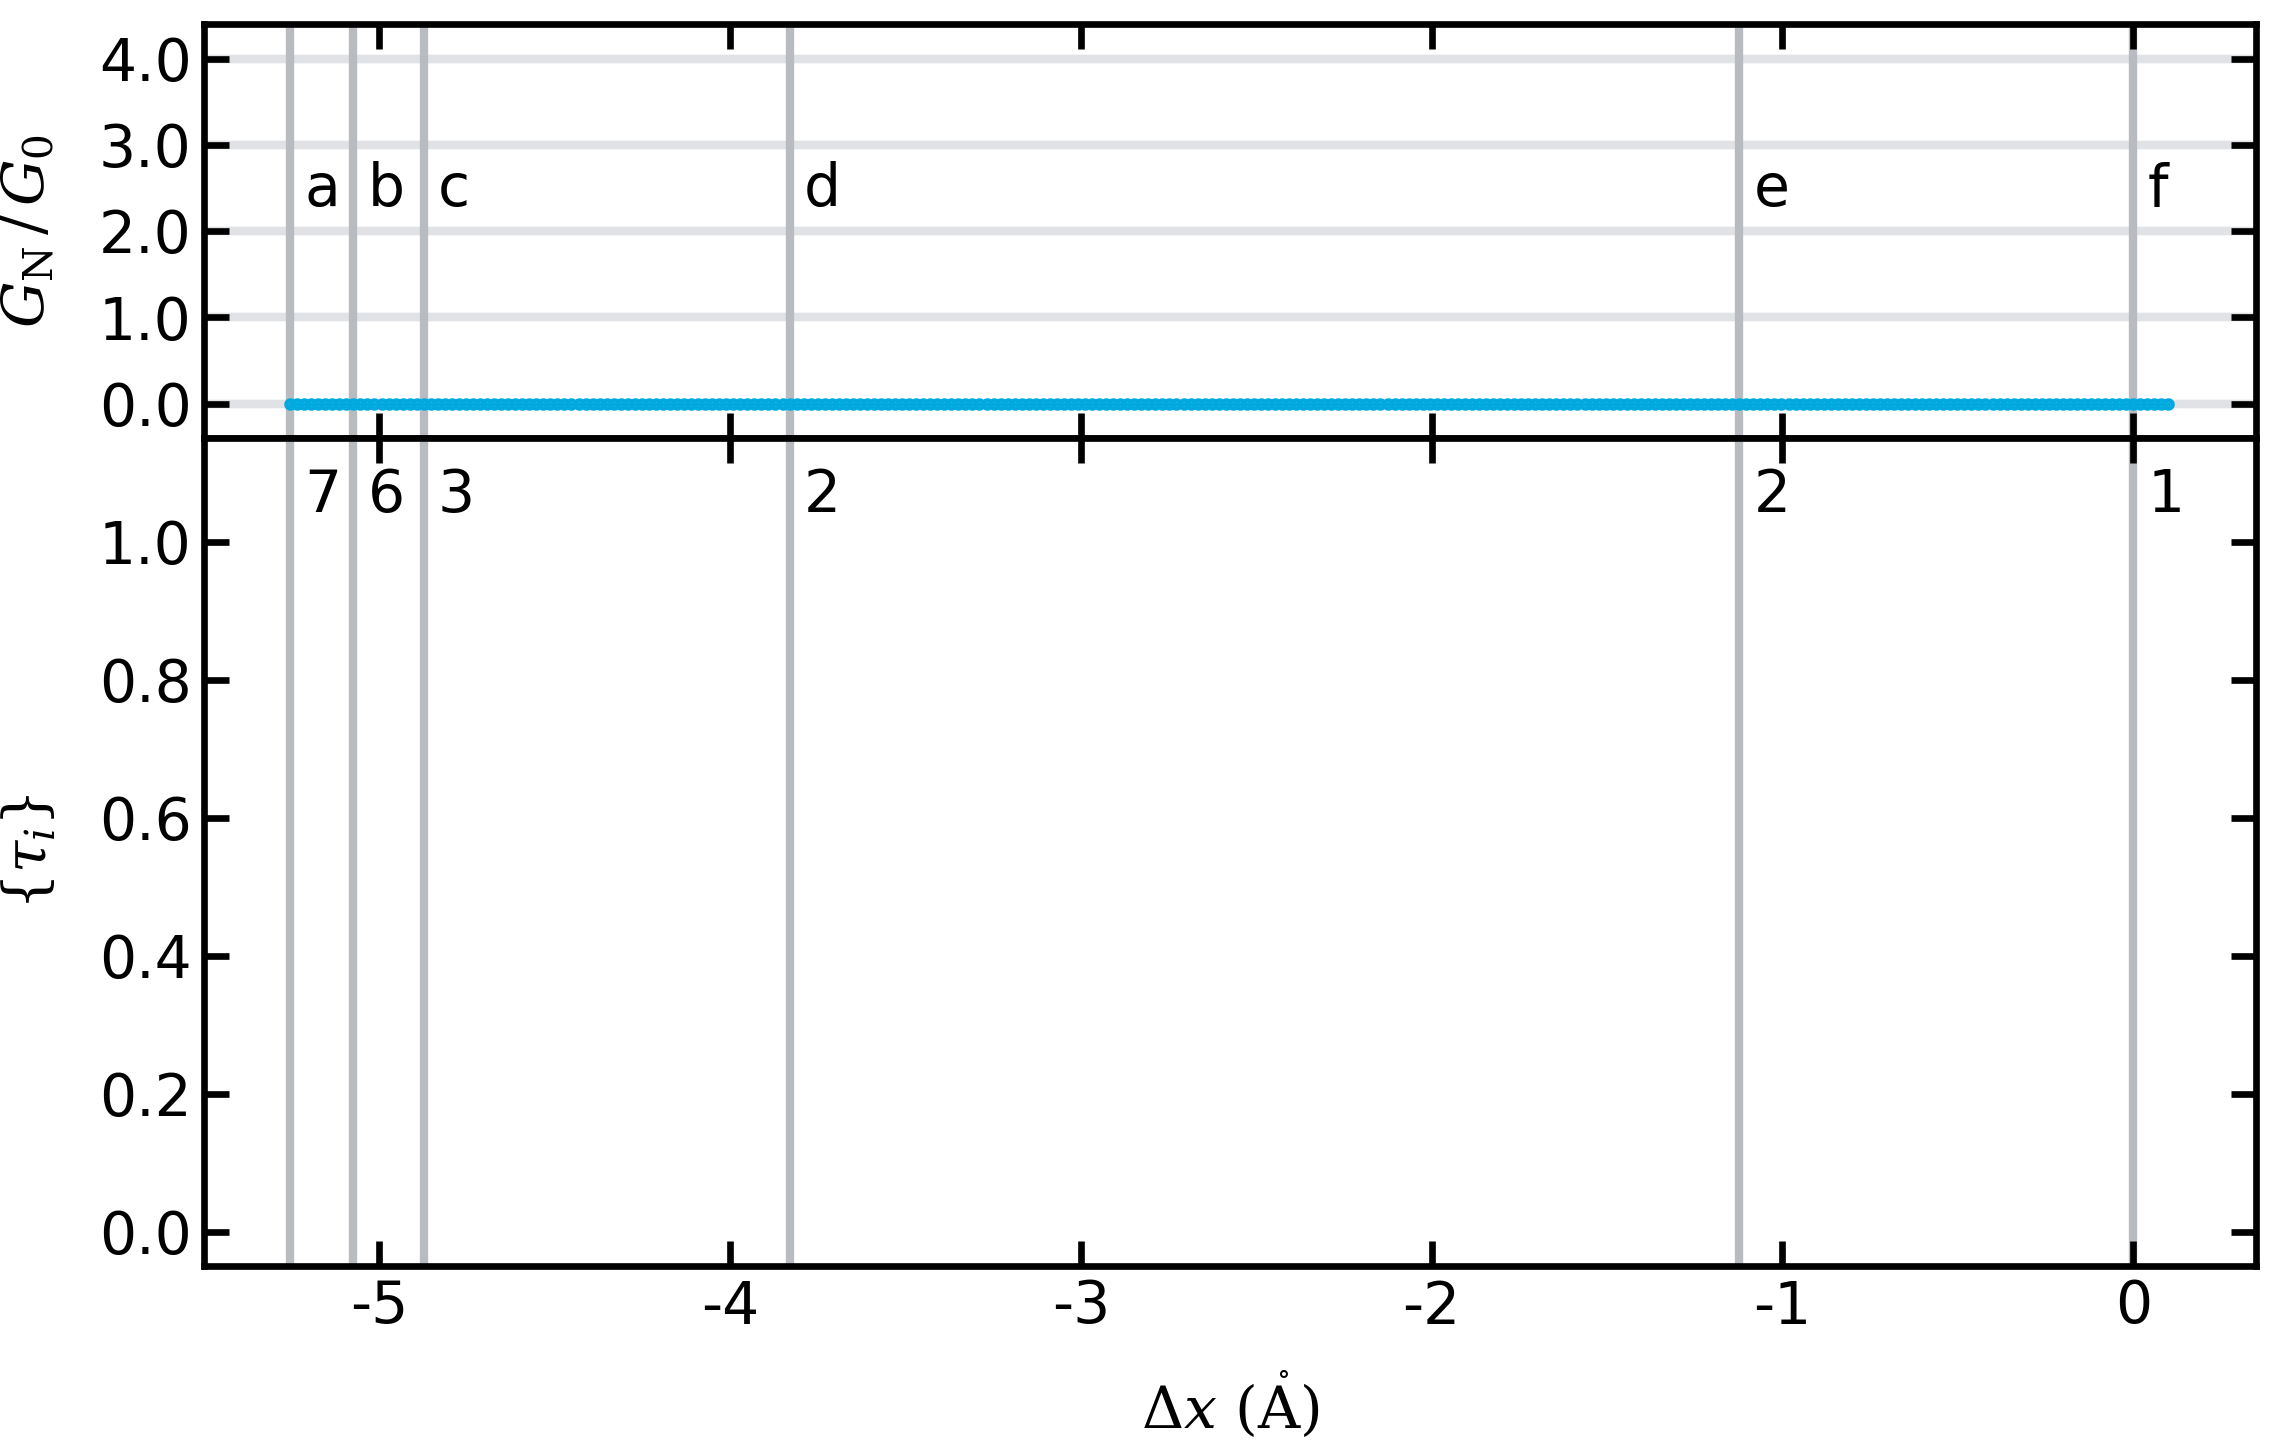

In [15]:
# pincode

colors = [
    sc.seeblau120,
    sc.seegrau120,
    sc.seeblau100,
    sc.seegrau100,
    sc.seeblau80,
    sc.seegrau80,
    sc.seeblau65,
    sc.seegrau65,
    sc.seeblau35,
    sc.seegrau35,
]
fig, axes = sc.get_figures(
    figsize=(3.8, 2.4),
    padding=(0.3, 0.25, 0.0, 0.0),
    nrows=2,
    ncols=1,
    height_ratios=[1, 2],
)
axes[0].plot(x_AA, GN_G0, ".", color=sc.seeblau100, label="$G_\\mathrm{N}\\,/\\,G_0$")

for i in range(12):
    axes[1].plot(
        x_AA,
        taus[:, i],
        ".",
        color=colors[i % 10],
        zorder=-i,
    )

axes[0].set_ylim((-0.4, 4.4))
axes[1].set_ylim((-0.05, 1.15))

for j, i in enumerate(i_skip):
    for ax in axes:
        ylim = ax.get_ylim()
        ax.vlines(x_AA[i], *ylim, color=sc.seegrau35, zorder=-10)
    axes[0].text(
        x_AA[i] + 0.04,
        2.15,
        regions[j],
        ha="left",
        va="bottom",
        size=7,
    )
    axes[1].text(
        x_AA[i] + 0.04,
        1.025,
        channels[j],
        ha="left",
        va="bottom",
        size=7,
    )

xlim = -5.5, 0.35
for ax in axes:
    ax.set_xlim(xlim)
    for x_i in [0, 1, 2, 3, 4]:
        axes[0].hlines(x_i, *xlim, color=sc.seegrau20, zorder=-20)
axes = sc.daumenkino_layout(
    fig,
    axes,
    title="atomic_contact/breaking/pincode",
    xlabel="$\\Delta x\\ (\mathring{\mathrm{A}})$",
    ylabel=[r"$G_\mathrm{N}\,/\,G_0$", r"$\{\tau_i\}$"],
    # xticks=[-2, -1, 0],
    yticks=[(0, 1, 2, 3, 4), (0, 0.2, 0.4, 0.6, 0.8, 1)],
    yticklabels=[
        (
            "0.0",
            "1.0",
            "2.0",
            "3.0",
            "4.0",
        ),
        ("0.0", "0.2", "0.4", "0.6", "0.8", "1.0"),
    ],
)
plt.show()

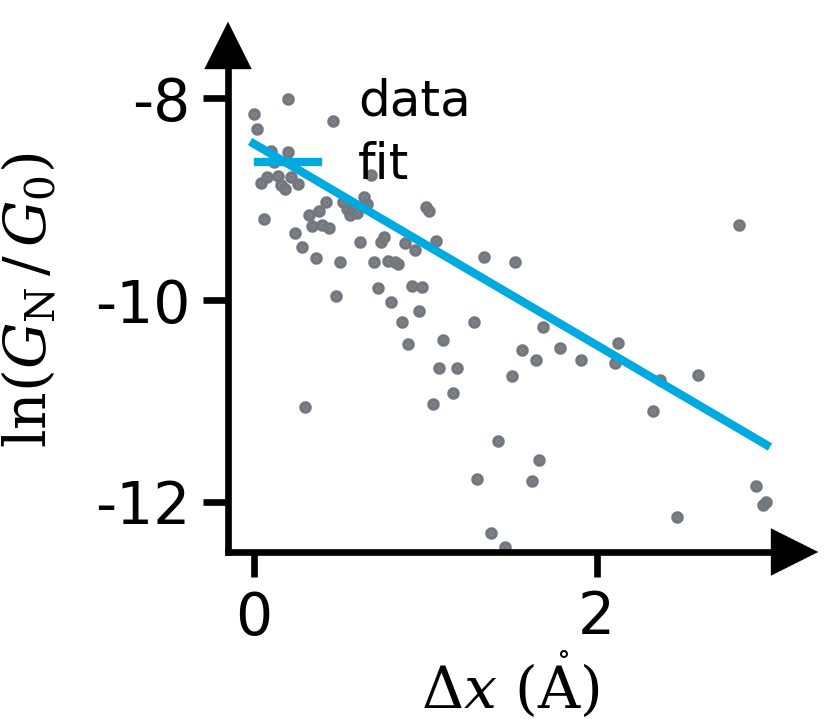

In [16]:
# tunneling
fig, ax = sc.get_figure(
    figsize=(1.4, 1.2),
    padding=(0.3, 0.2),
)
ax.plot(xtunnel_AA, lnGNtunnel_G0, ".", color=sc.seegrau100, label="data")
ax.plot(
    xtunnel_AA,
    linear(xtunnel_AA, -1, c / kappa_AA),
    "-",
    color=sc.seeblau100,
    label="fit",
)
ax.set_ylim(-12.5, -7.5)

ax.legend(
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

ax = sc.theory_layout(
    fig,
    ax,
    title="atomic_contact/breaking/tunneling",
    xlabel="$\\Delta x\\ (\\mathring{\\mathrm{A}})$",
    ylabel=r"$\mathrm{ln}\left(G_\mathrm{N}\,/\,G_0\right)$",
)

In [17]:
# histogram
counts, bins = np.histogram(taus, bins=100)
counts = np.array(counts, dtype=np.float64)
# counts[counts == 0] = np.nan
valid = counts != 0
# counts = counts
precounts = np.copy(counts)
counts = savgol_filter(counts, window_length=3, polyorder=0)
# counts = counts[5:]
# counts = savgol_filter(counts, window_length=10, polyorder=0)
# plt.plot(bins[5:-1], counts, ".")
tau_bins = np.linspace(0, 1, 100)

new_tau = np.linspace(0, 1.0, 101)
dtau = (new_tau[1] - new_tau[0]) / 4
counted = sc.nanbin_y_over_x(counts[valid], tau_bins[valid], new_tau)
sum_count = np.nansum(counted)

fig, ax = sc.get_figure(
    figsize=(1.4, 1.2),
    padding=(0.25, 0.2),
)
for i, tau_i in enumerate(new_tau):
    ax.fill_between(
        [tau_i - dtau, tau_i + dtau],
        y1=[0, 0],
        y2=[counted[i], counted[i]],
        color=sc.seeblau100,
    )
ax.set_ylim(0, 39)
ax.set_xlim(-0.05, 1.15)

ax = sc.theory_layout(
    fig,
    ax,
    title="atomic_contact/breaking/histogram",
    xlabel="$\\tau_i$",
    ylabel="$P\\left(\\tau_i\\right)$",
)
# plt.plot(tau_bins, counts, "k.")
# plt.plot(tau_bins, precounts, "r.-")

# plt.plot(new_tau, counted, ".")

ValueError: autodetected range of [nan, nan] is not finite

# Magnetic Field & Temperature Study

In [ ]:
# 550 G0, magnetic field
import numpy as np
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis
from superconductivity.utilities.functions.upsampling import upsample

data = np.load(
    f"550G0/magnetic-field/cal.npz",
)
Vbias0 = data["Vbias"]
Ibias0 = data["Ibias"]
uH0 = data["uH"]
Iexp0 = data["Iexp"]
Vexp0 = data["Vexp"]

uH = np.linspace(0, 1.0, 51)
Vbias = np.linspace(-0.6, 1.1, 501)
Ibias = np.linspace(-0.6, 1.1, 501)

Iexp1 = np.full((uH0.shape[0], Vbias.shape[0]), np.nan)
Vexp1 = np.full((uH0.shape[0], Ibias.shape[0]), np.nan)

for i, uh in enumerate(uH0):
    mask = np.isfinite(Iexp0[i, :])
    if np.sum(mask) > 2:
        Iexp1[i, :] = sc.nanbin_y_over_x(
            upsample(Iexp0[i, mask], axis=-1),
            upsample(Vbias0[mask], axis=-1),
            Vbias,
        )
    mask = np.isfinite(Vexp0[i, :])
    if np.sum(mask) > 2:
        Vexp1[i, :] = sc.nanbin_y_over_x(
            upsample(Vexp0[i, mask], axis=-1),
            upsample(Ibias0[mask], axis=-1),
            Ibias,
        )

Iexp = sc.nanbin_y_over_x(upsample(Iexp1, axis=0), upsample(uH0), uH, axis=0)
Vexp = sc.nanbin_y_over_x(upsample(Vexp1, axis=0), upsample(uH0), uH, axis=0)

dGexp = np.gradient(Iexp, Vbias, axis=-1)
dRexp = np.gradient(Vexp, Ibias, axis=-1)

exports = export_amplitude_maps_thesis(
    Vbias=Ibias,
    Abias=uH,
    Ibias=Vbias,
    Iexp=Vexp,
    dGexp=dRexp,
    dRexp=dGexp,
    Vbiaslim=(-0.6, 1.1),
    Abiaslim=(0.0, 1.0),
    Ibiaslim=(-0.6, 1.1),
    Ilim=(-0.6, 1.1),
    Ilabel="$V\\,/\\,I_\\mathrm{c}R_\\mathrm{N}$",
    Vlabel="$I\\,/\\,I_\\mathrm{c}$",
    Alabel="$H\\,/\\,H_\\mathrm{c}$",
    dGlabel=r"$\mathrm{d}V/\mathrm{d}I\,/\,R_\mathrm{N}$",
    dRlabel=r"$\mathrm{d}I/\mathrm{d}V\,\cdot\,R_\mathrm{N}$",
    Vbiasticks=[-0.5, 0, 0.5, 1.0],
    Abiasticks=[0, 0.2, 0.4, 0.6, 0.8],
    Ibiasticks=[-0.5, 0, 0.5, 1.0],
    Iticks=[-0.5, 0, 0.5, 1.0],
    waterfall_traces=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    name="cal",
    sub_dir=f"atomic_contact/550G0/magnetic-field",
)

In [ ]:
# 0.05 G0, magnetic field
import numpy as np
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis
from superconductivity.utilities.functions.upsampling import upsample

data = np.load(
    f"0.05G0/magnetic-field/cal.npz",
)
Vbias0 = data["Vbias"]
Ibias0 = data["Ibias"]
uH0 = data["uH"]
Iexp0 = data["Iexp"]

uH = np.linspace(0, 1.0, 51)
Vbias = np.linspace(-0.5, 3.0, 501)
Ibias = np.linspace(-0.5, 3.0, 501)

Iexp1 = np.full((uH0.shape[0], Vbias.shape[0]), np.nan)
Vexp1 = np.full((uH0.shape[0], Ibias.shape[0]), np.nan)

for i, uh in enumerate(uH0):
    mask = np.isfinite(Iexp0[i, :])
    if np.sum(mask) > 2:
        Iexp1[i, :] = sc.nanbin_y_over_x(
            upsample(Iexp0[i, mask], axis=-1),
            upsample(Vbias0[mask], axis=-1),
            Vbias,
        )
        Vexp1[i, :] = sc.nanbin_y_over_x(
            upsample(Vbias0[mask], axis=-1),
            upsample(Iexp0[i, mask], axis=-1),
            Ibias,
        )

Iexp = sc.nanbin_y_over_x(upsample(Iexp1, axis=0), upsample(uH0), uH, axis=0)
Vexp = sc.nanbin_y_over_x(upsample(Vexp1, axis=0), upsample(uH0), uH, axis=0)

dGexp = np.gradient(Iexp, Vbias, axis=-1)
dRexp = np.gradient(Vexp, Ibias, axis=-1)

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=uH,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    Vbiaslim=(-0.5, 3.0),
    Ibiaslim=(-0.5, 3.0),
    Abiaslim=(0, 1.0),
    Ilim=(-0.5, 3.0),
    dGlim=(0, 4.5),
    dRlim=(0, 4.5),
    Vbiasticks=[0, 1, 2],
    Ibiasticks=[0, 1, 2],
    Abiasticks=[0.0, 0.2, 0.4, 0.6, 0.8],
    Iticks=[0, 1, 2],
    dGticks=[0, 2, 4],
    dRticks=[0, 2, 4],
    Alabel="$H\\,/\\,H_\\mathrm{c}$",
    waterfall_traces=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    name="cal",
    sub_dir=f"atomic_contact/0.05G0/magnetic-field",
)

In [ ]:
# 0.05 G0, temperature study
import numpy as np
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis
from superconductivity.utilities.functions.upsampling import upsample

data = np.load(
    f"0.05G0/temperature/cal.npz",
)
Vbias0 = data["Vbias"]
Ibias0 = data["Ibias"]
Tbath0 = data["Tbath"]
Iexp0 = data["Iexp"]

Tbath = np.linspace(0.5, 1.0, 51)
Vbias = np.linspace(-0.5, 3.0, 501)
Ibias = np.linspace(-0.5, 2.99, 501)

Iexp1 = np.full((Tbath0.shape[0], Vbias.shape[0]), np.nan)
Vexp1 = np.full((Tbath0.shape[0], Ibias.shape[0]), np.nan)

for i, _ in enumerate(Tbath0):
    mask = np.isfinite(Iexp0[i, :])
    if np.sum(mask) > 2:
        Iexp1[i, :] = sc.nanbin_y_over_x(
            upsample(Iexp0[i, mask], axis=-1),
            upsample(Vbias0[mask], axis=-1),
            Vbias,
        )
        Vexp1[i, :] = sc.nanbin_y_over_x(
            upsample(Vbias0[mask], axis=-1),
            upsample(Iexp0[i, mask], axis=-1),
            Ibias,
        )

Iexp = sc.nanbin_y_over_x(
    upsample(Iexp1[30:, :], axis=0), upsample(Tbath0[30:]), Tbath, axis=0
)
Vexp = sc.nanbin_y_over_x(
    upsample(Vexp1[30:, :], axis=0), upsample(Tbath0[30:]), Tbath, axis=0
)

dGexp = np.gradient(Iexp, Vbias, axis=-1)
dRexp = np.gradient(Vexp, Ibias, axis=-1)

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Tbath,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    Vbiaslim=(-0.5, 3.0),
    Ibiaslim=(-0.5, 3.0),
    Abiaslim=(0.5, 1.0),
    Ilim=(-0.5, 3.0),
    dGlim=(0, 4.5),
    dRlim=(0, 4.5),
    Vbiasticks=[0, 1, 2],
    Ibiasticks=[0, 1, 2],
    Abiasticks=[0.5, 0.7, 0.9],
    Iticks=[0, 1, 2],
    dGticks=[0, 2, 4],
    dRticks=[0, 2, 4],
    Alabel="$T\\,/\\,T_\\mathrm{c}$",
    waterfall_traces=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    name="cal",
    sub_dir=f"atomic_contact/0.05G0/temperature",
)